In [1]:
# =============================================================
# Premature Convergence Detection
# Project 3 of 4 — Computational Accountability Framework
# =============================================================
# Research Question:
# Can we detect when a reasoning process closes too early
# on a single explanation, despite available alternatives?
#
# Ground truth definition (after Kim, 2026):
# Premature convergence at time t =
# low explanatory diversity + high attribution commitment,
# despite later evidence showing alternatives were available.
# =============================================================

import pandas as pd
import numpy as np
from collections import Counter
import json

print("Environment ready!")

Environment ready!


In [2]:
# -------------------------------------------------------------
# Step 1: Create synthetic reasoning log data
# Each case = one investigation
# Each step = one time point in the reasoning process
# -------------------------------------------------------------

case_001 = [
    {
        "case_id": "case_001",
        "step": 1,
        "time_min": 2,
        "dominant_attribution": "individual",
        "explanation_count": 1,
        "explanation_categories": ["human_error"],
        "commitment_level": "high",
        "uncertainty_marker": False,
        "alternative_considered": False,
        "closure_language": True,
        "later_revision": True   # step 2 shows new explanations → this step is premature
    },
    {
        "case_id": "case_001",
        "step": 2,
        "time_min": 8,
        "dominant_attribution": "mixed",
        "explanation_count": 3,
        "explanation_categories": ["human_error", "training", "SOP"],
        "commitment_level": "low",
        "uncertainty_marker": True,
        "alternative_considered": True,
        "closure_language": False,
        "later_revision": False
    },
]

print(f"Case 001: {len(case_001)} steps")
print(f"Step 1 — explanation count: {case_001[0]['explanation_count']}, commitment: {case_001[0]['commitment_level']}")
print(f"Step 2 — explanation count: {case_001[1]['explanation_count']}, commitment: {case_001[1]['commitment_level']}")

Case 001: 2 steps
Step 1 — explanation count: 1, commitment: high
Step 2 — explanation count: 3, commitment: low


In [3]:
# -------------------------------------------------------------
# Step 2: Build a dataset with multiple cases
# Mix of premature (label=1) and non-premature (label=0) cases
# -------------------------------------------------------------

dataset = [
    # PREMATURE CASES (label = 1)
    # Early closure, low diversity, later revised
    {"case_id": "case_001", "step": 1, "explanation_count": 1,
     "commitment_level": 2, "uncertainty_marker": 0,
     "alternative_considered": 0, "closure_language": 1,
     "later_revision": 1, "label": 1},

    {"case_id": "case_002", "step": 1, "explanation_count": 1,
     "commitment_level": 2, "uncertainty_marker": 0,
     "alternative_considered": 0, "closure_language": 1,
     "later_revision": 1, "label": 1},

    {"case_id": "case_003", "step": 1, "explanation_count": 1,
     "commitment_level": 2, "uncertainty_marker": 0,
     "alternative_considered": 1, "closure_language": 1,
     "later_revision": 1, "label": 1},

    # NON-PREMATURE CASES (label = 0)
    # Open reasoning, high diversity, no early closure
    {"case_id": "case_004", "step": 1, "explanation_count": 3,
     "commitment_level": 0, "uncertainty_marker": 1,
     "alternative_considered": 1, "closure_language": 0,
     "later_revision": 0, "label": 0},

    {"case_id": "case_005", "step": 1, "explanation_count": 4,
     "commitment_level": 0, "uncertainty_marker": 1,
     "alternative_considered": 1, "closure_language": 0,
     "later_revision": 0, "label": 0},

    {"case_id": "case_006", "step": 1, "explanation_count": 2,
     "commitment_level": 1, "uncertainty_marker": 1,
     "alternative_considered": 1, "closure_language": 0,
     "later_revision": 0, "label": 0},
]

df = pd.DataFrame(dataset)
print(df)
print(f"\nTotal cases: {len(df)}")
print(f"Premature (1): {df['label'].sum()}")
print(f"Non-premature (0): {len(df) - df['label'].sum()}")

    case_id  step  explanation_count  commitment_level  uncertainty_marker  \
0  case_001     1                  1                 2                   0   
1  case_002     1                  1                 2                   0   
2  case_003     1                  1                 2                   0   
3  case_004     1                  3                 0                   1   
4  case_005     1                  4                 0                   1   
5  case_006     1                  2                 1                   1   

   alternative_considered  closure_language  later_revision  label  
0                       0                 1               1      1  
1                       0                 1               1      1  
2                       1                 1               1      1  
3                       1                 0               0      0  
4                       1                 0               0      0  
5                       1              

In [4]:
# -------------------------------------------------------------
# Step 3: Rule-based synthetic dataset generator
# Labels are assigned automatically based on convergence rules
# -------------------------------------------------------------

import random
random.seed(42)  # for reproducibility

EXPLANATION_CATEGORIES = [
    "human_error", "training", "SOP", 
    "equipment", "process_design", 
    "management", "environmental"
]

def generate_case(case_id):
    # Randomly sample features
    explanation_count = random.randint(1, 5)
    explanation_categories = random.sample(
        EXPLANATION_CATEGORIES, 
        min(explanation_count, len(EXPLANATION_CATEGORIES))
    )
    commitment_level = random.randint(0, 2)   # 0=low, 1=medium, 2=high
    uncertainty_marker = random.randint(0, 1)
    alternative_considered = random.randint(0, 1)
    closure_language = random.randint(0, 1)
    later_revision = random.randint(0, 1)

    # Rule-based label (after Kim, 2026)
    # Premature = 1 if:
    # - explanation_count <= 1
    # - commitment_level == high (2)
    # - alternative_considered == False
    # - later_revision == True
    if (explanation_count <= 1 and 
        commitment_level == 2 and 
        alternative_considered == 0 and 
        later_revision == 1):
        label = 1
    else:
        label = 0

    return {
        "case_id": f"case_{case_id:03d}",
        "explanation_count": explanation_count,
        "explanation_categories": explanation_categories,
        "commitment_level": commitment_level,
        "uncertainty_marker": uncertainty_marker,
        "alternative_considered": alternative_considered,
        "closure_language": closure_language,
        "later_revision": later_revision,
        "label": label
    }

# Generate 300 cases
cases = [generate_case(i) for i in range(300)]
df = pd.DataFrame(cases)

print(f"Total cases: {len(df)}")
print(f"Premature (1): {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
print(f"Non-premature (0): {len(df) - df['label'].sum()} ({(1-df['label'].mean())*100:.1f}%)")

Total cases: 300
Premature (1): 6 (2.0%)
Non-premature (0): 294 (98.0%)


In [5]:
# -------------------------------------------------------------
# Step 4: Balanced dataset generator (150 premature + 150 non-premature)
# -------------------------------------------------------------

def generate_premature_case(case_id):
    """Generate a case that is premature (label=1)"""
    explanation_count = random.randint(1, 2)  # low diversity
    explanation_categories = random.sample(EXPLANATION_CATEGORIES, explanation_count)
    commitment_level = random.randint(1, 2)   # medium or high
    uncertainty_marker = random.randint(0, 1)
    alternative_considered = 0               # no alternatives considered
    closure_language = random.randint(0, 1)
    later_revision = 1                       # always revised later

    return {
        "case_id": f"premature_{case_id:03d}",
        "explanation_count": explanation_count,
        "explanation_categories": explanation_categories,
        "commitment_level": commitment_level,
        "uncertainty_marker": uncertainty_marker,
        "alternative_considered": alternative_considered,
        "closure_language": closure_language,
        "later_revision": later_revision,
        "label": 1
    }

def generate_nonpremature_case(case_id):
    """Generate a case that is not premature (label=0)"""
    explanation_count = random.randint(3, 6)  # high diversity
    explanation_categories = random.sample(
        EXPLANATION_CATEGORIES, 
        min(explanation_count, len(EXPLANATION_CATEGORIES))
    )
    commitment_level = random.randint(0, 1)   # low or medium
    uncertainty_marker = random.randint(0, 1)
    alternative_considered = 1               # alternatives always considered
    closure_language = 0                     # no closure language
    later_revision = random.randint(0, 1)

    return {
        "case_id": f"nonpremature_{case_id:03d}",
        "explanation_count": explanation_count,
        "explanation_categories": explanation_categories,
        "commitment_level": commitment_level,
        "uncertainty_marker": uncertainty_marker,
        "alternative_considered": alternative_considered,
        "closure_language": closure_language,
        "later_revision": later_revision,
        "label": 0
    }

# Generate balanced dataset
premature_cases = [generate_premature_case(i) for i in range(150)]
nonpremature_cases = [generate_nonpremature_case(i) for i in range(150)]
all_cases = premature_cases + nonpremature_cases

# Shuffle
random.shuffle(all_cases)
df = pd.DataFrame(all_cases)

print(f"Total cases: {len(df)}")
print(f"Premature (1): {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
print(f"Non-premature (0): {len(df) - df['label'].sum()} ({(1-df['label'].mean())*100:.1f}%)")
print(f"\nFeature preview:")
print(df.drop(columns=['case_id', 'explanation_categories']).head())

Total cases: 300
Premature (1): 150 (50.0%)
Non-premature (0): 150 (50.0%)

Feature preview:
   explanation_count  commitment_level  uncertainty_marker  \
0                  1                 1                   0   
1                  4                 0                   0   
2                  2                 1                   1   
3                  4                 1                   0   
4                  6                 0                   0   

   alternative_considered  closure_language  later_revision  label  
0                       0                 1               1      1  
1                       1                 0               1      0  
2                       0                 1               1      1  
3                       1                 0               1      0  
4                       1                 0               0      0  


In [6]:
# -------------------------------------------------------------
# Step 5: Add entropy-based diversity score
# Entropy = measure of how spread out the explanations are
# High entropy = many diverse explanations = open reasoning
# Low entropy = one dominant explanation = closed reasoning
# -------------------------------------------------------------

from scipy.stats import entropy

def compute_diversity_score(explanation_categories):
    if not explanation_categories:
        return 0.0
    counts = Counter(explanation_categories)
    total = sum(counts.values())
    probs = [v / total for v in counts.values()]
    return entropy(probs, base=2)  # bits

# Apply to dataset
df['diversity_score'] = df['explanation_categories'].apply(compute_diversity_score)

print("Diversity score added!")
print(f"\nPremature cases — avg diversity: {df[df['label']==1]['diversity_score'].mean():.3f}")
print(f"Non-premature cases — avg diversity: {df[df['label']==0]['diversity_score'].mean():.3f}")
print(f"\nPreview:")
print(df[['explanation_count', 'diversity_score', 'label']].head(10))

Diversity score added!

Premature cases — avg diversity: 0.493
Non-premature cases — avg diversity: 2.129

Preview:
   explanation_count  diversity_score  label
0                  1         0.000000      1
1                  4         2.000000      0
2                  2         1.000000      1
3                  4         2.000000      0
4                  6         2.584963      0
5                  6         2.584963      0
6                  6         2.584963      0
7                  3         1.584963      0
8                  1         0.000000      1
9                  4         2.000000      0


In [7]:
# -------------------------------------------------------------
# Step 6: Logistic Regression classifier + feature importance
# -------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Features and label
features = [
    'explanation_count', 
    'commitment_level',
    'uncertainty_marker', 
    'alternative_considered',
    'closure_language', 
    'later_revision',
    'diversity_score'
]

X = df[features]
y = df['label']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Non-premature', 'Premature']))

# Feature importance
print("\nFeature Importance (coefficients):")
for feat, coef in sorted(zip(features, model.coef_[0]), 
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:25s}: {coef:+.3f}")

Accuracy: 1.000

Classification Report:
               precision    recall  f1-score   support

Non-premature       1.00      1.00      1.00        30
    Premature       1.00      1.00      1.00        30

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60


Feature Importance (coefficients):
  explanation_count        : -2.159
  alternative_considered   : -1.888
  diversity_score          : -1.252
  commitment_level         : +1.043
  closure_language         : +0.693
  later_revision           : +0.583
  uncertainty_marker       : +0.055


In [8]:
# -------------------------------------------------------------
# Step 7: Add noise to make the dataset more realistic
# Real data is messy — not every premature case looks obvious
# -------------------------------------------------------------

def add_noise(df, noise_rate=0.15):
    """
    Randomly flip some feature values to simulate real-world messiness.
    noise_rate = proportion of rows to add noise to
    """
    df_noisy = df.copy()
    n_noisy = int(len(df) * noise_rate)
    noisy_indices = random.sample(range(len(df)), n_noisy)
    
    for idx in noisy_indices:
        # Randomly pick a feature to flip
        feature_to_flip = random.choice([
            'commitment_level',
            'uncertainty_marker', 
            'alternative_considered',
            'closure_language'
        ])
        
        if feature_to_flip == 'commitment_level':
            # Shift commitment level by 1
            current = df_noisy.at[idx, 'commitment_level']
            df_noisy.at[idx, 'commitment_level'] = min(2, current + 1) \
                if random.random() > 0.5 else max(0, current - 1)
        else:
            # Flip binary feature
            df_noisy.at[idx, feature_to_flip] = 1 - df_noisy.at[idx, feature_to_flip]
    
    return df_noisy

# Apply noise
df_noisy = add_noise(df, noise_rate=0.15)

# Retrain and evaluate
X_noisy = df_noisy[features]
y_noisy = df_noisy['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y_noisy, test_size=0.2, random_state=42, stratify=y_noisy
)

model_noisy = LogisticRegression(random_state=42)
model_noisy.fit(X_train, y_train)
y_pred = model_noisy.predict(X_test)

print(f"Accuracy (with noise): {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-premature', 'Premature']))

print("\nFeature Importance (with noise):")
for feat, coef in sorted(zip(features, model_noisy.coef_[0]),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:25s}: {coef:+.3f}")

Accuracy (with noise): 1.000

Classification Report:
               precision    recall  f1-score   support

Non-premature       1.00      1.00      1.00        30
    Premature       1.00      1.00      1.00        30

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60


Feature Importance (with noise):
  explanation_count        : -2.314
  alternative_considered   : -1.682
  diversity_score          : -1.363
  commitment_level         : +0.993
  later_revision           : +0.729
  closure_language         : +0.646
  uncertainty_marker       : -0.058


In [9]:
# -------------------------------------------------------------
# Step 8: Remove future information from features
# In real detection, we don't know if later_revision will happen
# Model should predict premature convergence WITHOUT that info
# -------------------------------------------------------------

features_realistic = [
    'explanation_count',
    'commitment_level', 
    'uncertainty_marker',
    'alternative_considered',
    'closure_language',
    'diversity_score'
    # later_revision REMOVED — this is future information
]

X_realistic = df_noisy[features_realistic]
y_realistic = df_noisy['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_realistic, y_realistic, 
    test_size=0.2, random_state=42, stratify=y_realistic
)

model_realistic = LogisticRegression(random_state=42)
model_realistic.fit(X_train, y_train)
y_pred = model_realistic.predict(X_test)

print(f"Accuracy (realistic features): {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-premature', 'Premature']))

print("\nFeature Importance:")
for feat, coef in sorted(zip(features_realistic, model_realistic.coef_[0]),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:25s}: {coef:+.3f}")

Accuracy (realistic features): 1.000

Classification Report:
               precision    recall  f1-score   support

Non-premature       1.00      1.00      1.00        30
    Premature       1.00      1.00      1.00        30

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60


Feature Importance:
  explanation_count        : -2.424
  alternative_considered   : -1.700
  diversity_score          : -1.426
  commitment_level         : +0.988
  closure_language         : +0.664
  uncertainty_marker       : -0.033


In [10]:
# -------------------------------------------------------------
# Step 9: Redesign — remove alternative_considered from label rule
# Add genuinely ambiguous cases to break perfect separation
# -------------------------------------------------------------

def generate_case_v2(case_id):
    explanation_count = random.randint(1, 6)
    explanation_categories = random.sample(
        EXPLANATION_CATEGORIES,
        min(explanation_count, len(EXPLANATION_CATEGORIES))
    )
    commitment_level = random.randint(0, 2)
    uncertainty_marker = random.randint(0, 1)
    alternative_considered = random.randint(0, 1)  # NOT in label rule anymore
    closure_language = random.randint(0, 1)
    later_revision = random.randint(0, 1)

    # Simplified label rule — only 2 core conditions
    # Premature = low diversity + high commitment + later revised
    diversity = entropy(
        [1/len(explanation_categories)] * len(explanation_categories), 
        base=2
    ) if explanation_categories else 0.0

    if (explanation_count <= 2 and
        commitment_level == 2 and
        later_revision == 1):
        label = 1
    else:
        label = 0

    return {
        "case_id": f"case_v2_{case_id:03d}",
        "explanation_count": explanation_count,
        "explanation_categories": explanation_categories,
        "commitment_level": commitment_level,
        "uncertainty_marker": uncertainty_marker,
        "alternative_considered": alternative_considered,
        "closure_language": closure_language,
        "later_revision": later_revision,
        "diversity_score": diversity,
        "label": label
    }

# Generate 500 cases
random.seed(42)
cases_v2 = [generate_case_v2(i) for i in range(500)]
df_v2 = pd.DataFrame(cases_v2)

print(f"Total: {len(df_v2)}")
print(f"Premature (1): {df_v2['label'].sum()} ({df_v2['label'].mean()*100:.1f}%)")
print(f"Non-premature (0): {len(df_v2) - df_v2['label'].sum()} ({(1-df_v2['label'].mean())*100:.1f}%)")

Total: 500
Premature (1): 24 (4.8%)
Non-premature (0): 476 (95.2%)


In [11]:
# -------------------------------------------------------------
# Step 10: Probabilistic labeling — more realistic
# Label is based on risk score + randomness
# This creates genuinely ambiguous cases
# -------------------------------------------------------------

def compute_risk_score(row):
    """
    Risk score = weighted sum of convergence signals
    Higher score = higher chance of being premature
    """
    score = 0.0
    score += (3 - row['explanation_count']) * 0.3   # fewer explanations = higher risk
    score += row['commitment_level'] * 0.3           # higher commitment = higher risk
    score += (1 - row['uncertainty_marker']) * 0.2  # no uncertainty = higher risk
    score += row['closure_language'] * 0.2           # closure language = higher risk
    return score

def generate_case_v3(case_id):
    explanation_count = random.randint(1, 6)
    explanation_categories = random.sample(
        EXPLANATION_CATEGORIES,
        min(explanation_count, len(EXPLANATION_CATEGORIES))
    )
    commitment_level = random.randint(0, 2)
    uncertainty_marker = random.randint(0, 1)
    alternative_considered = random.randint(0, 1)
    closure_language = random.randint(0, 1)
    later_revision = random.randint(0, 1)
    diversity_score = entropy(
        [1/len(explanation_categories)] * len(explanation_categories),
        base=2
    ) if explanation_categories else 0.0

    # Compute risk score
    row = {
        'explanation_count': explanation_count,
        'commitment_level': commitment_level,
        'uncertainty_marker': uncertainty_marker,
        'closure_language': closure_language
    }
    risk = compute_risk_score(row)

    # Probabilistic label — higher risk = more likely premature
    # Add noise so it's not perfectly separable
    threshold = 0.5
    noise = random.gauss(0, 0.15)  # gaussian noise
    label = 1 if (risk + noise) > threshold else 0

    return {
        "case_id": f"case_v3_{case_id:03d}",
        "explanation_count": explanation_count,
        "explanation_categories": explanation_categories,
        "commitment_level": commitment_level,
        "uncertainty_marker": uncertainty_marker,
        "alternative_considered": alternative_considered,
        "closure_language": closure_language,
        "later_revision": later_revision,
        "diversity_score": diversity_score,
        "label": label
    }

# Generate 500 cases
random.seed(42)
cases_v3 = [generate_case_v3(i) for i in range(500)]
df_v3 = pd.DataFrame(cases_v3)

print(f"Total: {len(df_v3)}")
print(f"Premature (1): {df_v3['label'].sum()} ({df_v3['label'].mean()*100:.1f}%)")
print(f"Non-premature (0): {len(df_v3) - df_v3['label'].sum()} ({(1-df_v3['label'].mean())*100:.1f}%)")

Total: 500
Premature (1): 210 (42.0%)
Non-premature (0): 290 (58.0%)


In [12]:
# -------------------------------------------------------------
# Step 11: Train Logistic Regression on v3 dataset
# -------------------------------------------------------------

features_v3 = [
    'explanation_count',
    'commitment_level',
    'uncertainty_marker',
    'alternative_considered',
    'closure_language',
    'diversity_score'
]

X_v3 = df_v3[features_v3]
y_v3 = df_v3['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_v3, y_v3,
    test_size=0.2, random_state=42, stratify=y_v3
)

model_v3 = LogisticRegression(random_state=42)
model_v3.fit(X_train, y_train)
y_pred = model_v3.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-premature', 'Premature']))

print("\nFeature Importance:")
for feat, coef in sorted(zip(features_v3, model_v3.coef_[0]),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:25s}: {coef:+.3f}")

Accuracy: 0.890

Classification Report:
               precision    recall  f1-score   support

Non-premature       0.94      0.86      0.90        58
    Premature       0.83      0.93      0.88        42

     accuracy                           0.89       100
    macro avg       0.89      0.90      0.89       100
 weighted avg       0.90      0.89      0.89       100


Feature Importance:
  commitment_level         : +2.408
  explanation_count        : -2.341
  uncertainty_marker       : -2.032
  closure_language         : +1.769
  alternative_considered   : +0.776
  diversity_score          : -0.548


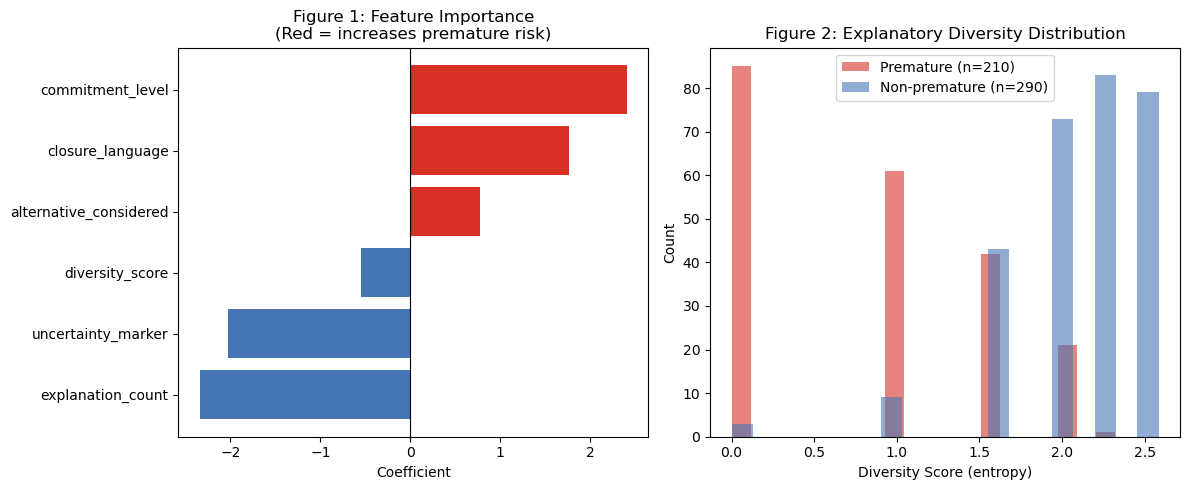

Saved as figures.png!


In [13]:
# -------------------------------------------------------------
# Step 12: Visualize results — Figure 1 & 2
# -------------------------------------------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Figure 1 — Feature Importance
features_sorted = sorted(zip(features_v3, model_v3.coef_[0]),
                         key=lambda x: x[1])
feat_names = [f[0] for f in features_sorted]
feat_coefs = [f[1] for f in features_sorted]
colors = ['#d73027' if c > 0 else '#4575b4' for c in feat_coefs]

axes[0].barh(feat_names, feat_coefs, color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('Figure 1: Feature Importance\n(Red = increases premature risk)')

# Figure 2 — Diversity score distribution by label
premature_div = df_v3[df_v3['label']==1]['diversity_score']
nonpremature_div = df_v3[df_v3['label']==0]['diversity_score']

axes[1].hist(premature_div, bins=20, alpha=0.6, 
             color='#d73027', label=f'Premature (n={len(premature_div)})')
axes[1].hist(nonpremature_div, bins=20, alpha=0.6,
             color='#4575b4', label=f'Non-premature (n={len(nonpremature_div)})')
axes[1].set_xlabel('Diversity Score (entropy)')
axes[1].set_ylabel('Count')
axes[1].set_title('Figure 2: Explanatory Diversity Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as figures.png!")

In [15]:
# -------------------------------------------------------------
# Step 13: Load FDA Warning Letter corpus for validation
# -------------------------------------------------------------

fda_df = pd.read_excel(r'C:\Users\user\FDA_Warning Letter.xlsx')

print(f"Shape: {fda_df.shape}")
print(f"Columns: {fda_df.columns.tolist()}")
print(f"\nResponsibilitySubject distribution:")
print(fda_df['ResponsibilitySubject'].value_counts())
print(f"\nPreview:")
print(fda_df.head())

Shape: (160, 5)
Columns: ['CaseID', 'ViolationID', 'CFR', 'ResponsibilitySubject', 'ViolationText']

ResponsibilitySubject distribution:
ResponsibilitySubject
Firm                  159
QualityControlUnit      1
Name: count, dtype: int64

Preview:
      CaseID ViolationID                 CFR ResponsibilitySubject  \
0  WL2016-01          V1  211.42(c)(10)(iv))                  Firm   
1  WL2016-01          V2          211.113(b)                  Firm   
2  WL2016-02          V1       211.194(a)(4)                  Firm   
3  WL2016-02          V2             211.192                  Firm   
4  WL2016-03          V1             211.192                  Firm   

                     ViolationText  
0  environmental monitoring system  
1               written procedures  
2    laboratory records incomplete  
3   investigation of discrepancies  
4        OOS investigation failure  


In [16]:
# -------------------------------------------------------------
# Step 14: Convert to case-level features for validation
# Each CaseID = one investigation = one reasoning process
# -------------------------------------------------------------

case_level = fda_df.groupby('CaseID').agg(
    violation_count=('ViolationID', 'count'),
    unique_cfr_count=('CFR', 'nunique'),
    violation_texts=('ViolationText', list)
).reset_index()

# Compute CFR diversity score (entropy)
def cfr_diversity(cfr_series):
    counts = fda_df[fda_df['CaseID'] == cfr_series.name]['CFR'].value_counts()
    probs = counts / counts.sum()
    return entropy(probs, base=2)

case_level['diversity_score'] = case_level['CaseID'].apply(
    lambda cid: entropy(
        (fda_df[fda_df['CaseID']==cid]['CFR']
         .value_counts() / 
         fda_df[fda_df['CaseID']==cid]['CFR'].count()).values,
        base=2
    )
)

print(f"Total cases: {len(case_level)}")
print(f"\nViolation count stats:")
print(case_level['violation_count'].describe())
print(f"\nDiversity score stats:")
print(case_level['diversity_score'].describe())
print(f"\nPreview:")
print(case_level[['CaseID', 'violation_count', 'unique_cfr_count', 'diversity_score']].head(10))

Total cases: 50

Violation count stats:
count    50.000000
mean      3.200000
std       1.030158
min       1.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       6.000000
Name: violation_count, dtype: float64

Diversity score stats:
count    50.000000
mean      1.601276
std       0.488666
min       0.000000
25%       1.584963
50%       1.584963
75%       2.000000
max       2.584963
Name: diversity_score, dtype: float64

Preview:
      CaseID  violation_count  unique_cfr_count  diversity_score
0  WL2016-01                2                 2         1.000000
1  WL2016-02                2                 2         1.000000
2  WL2016-03                6                 6         2.584963
3  WL2016-04                2                 2         1.000000
4  WL2016-05                3                 3         1.584963
5  WL2017-01                4                 4         2.000000
6  WL2017-02                2                 2         1.000000
7  WL2017-03              

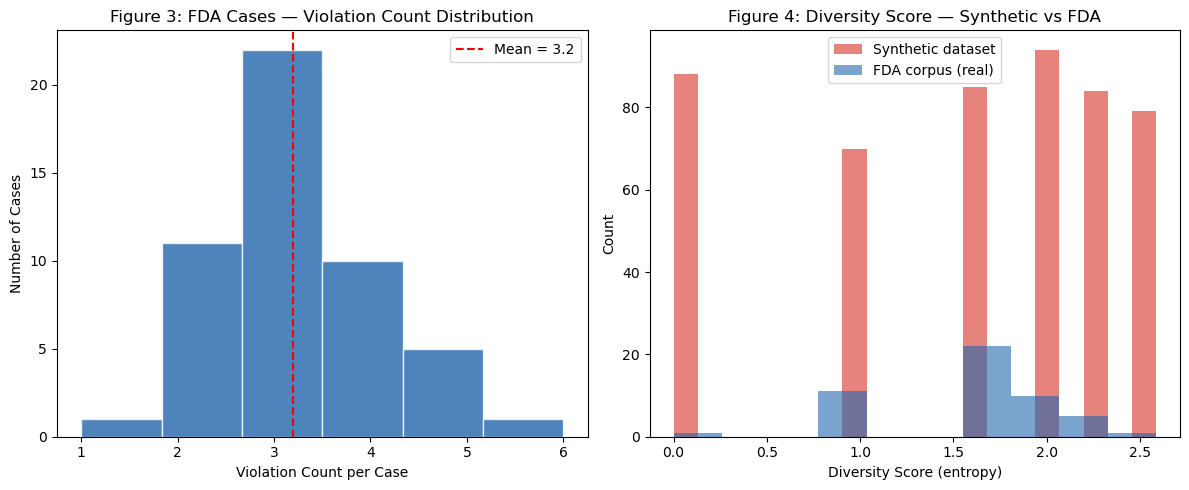


Synthetic avg diversity: 1.584
FDA corpus avg diversity: 1.601


In [17]:
# -------------------------------------------------------------
# Step 15: Compare FDA corpus vs synthetic dataset
# Validation: do real cases follow similar patterns?
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Figure 3 — Violation count distribution
axes[0].hist(case_level['violation_count'], bins=6, 
             color='#2166ac', alpha=0.8, edgecolor='white')
axes[0].axvline(case_level['violation_count'].mean(), 
                color='red', linestyle='--', 
                label=f"Mean = {case_level['violation_count'].mean():.1f}")
axes[0].set_xlabel('Violation Count per Case')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Figure 3: FDA Cases — Violation Count Distribution')
axes[0].legend()

# Figure 4 — Diversity score: FDA vs synthetic
axes[1].hist(df_v3['diversity_score'], bins=20, alpha=0.6,
             color='#d73027', label='Synthetic dataset')
axes[1].hist(case_level['diversity_score'], bins=10, alpha=0.6,
             color='#2166ac', label='FDA corpus (real)')
axes[1].set_xlabel('Diversity Score (entropy)')
axes[1].set_ylabel('Count')
axes[1].set_title('Figure 4: Diversity Score — Synthetic vs FDA')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures_fda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSynthetic avg diversity: {df_v3['diversity_score'].mean():.3f}")
print(f"FDA corpus avg diversity: {case_level['diversity_score'].mean():.3f}")

In [18]:
# -------------------------------------------------------------
# Step 16: Extract text features from ViolationText
# Which words signal premature convergence in real documents?
# -------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

# Combine all violation texts per case
case_texts = fda_df.groupby('CaseID')['ViolationText'].apply(
    lambda x: ' '.join(x)
).reset_index()
case_texts.columns = ['CaseID', 'combined_text']

# Merge with case_level
case_level = case_level.merge(case_texts, on='CaseID')

# TF-IDF on violation texts
vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(case_level['combined_text'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=vectorizer.get_feature_names_out()
)

print("Top 20 TF-IDF terms across FDA corpus:")
print(vectorizer.get_feature_names_out())
print(f"\nTF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nPreview:")
print(tfidf_df.head())

Top 20 TF-IDF terms across FDA corpus:
['cleaning' 'control' 'controls' 'data' 'equipment' 'failure' 'inadequate'
 'laboratory' 'manufacturing' 'oversight' 'perform' 'procedures' 'process'
 'product' 'quality' 'release' 'stability' 'testing' 'unit' 'validation']

TF-IDF matrix shape: (50, 20)

Preview:
   cleaning   control  controls      data  equipment   failure  inadequate  \
0       0.0  0.000000       0.0  0.000000   0.000000  0.000000    0.000000   
1       0.0  0.000000       0.0  0.000000   0.000000  0.000000    0.000000   
2       0.0  0.000000       0.0  0.383199   0.000000  0.249428    0.000000   
3       0.0  0.000000       0.0  0.000000   0.557883  0.425952    0.000000   
4       0.0  0.345115       0.0  0.000000   0.000000  0.296485    0.237355   

   laboratory  manufacturing  oversight  perform  procedures   process  \
0         0.0            0.0   0.000000      0.0    1.000000  0.000000   
1         1.0            0.0   0.000000      0.0    0.000000  0.000000   
2    

In [19]:
# -------------------------------------------------------------
# Step 17: Compute convergence risk score for FDA cases
# Combine structural features + text features
# -------------------------------------------------------------

# Merge tfidf with case_level
case_features = pd.concat([
    case_level[['CaseID', 'violation_count', 'diversity_score']].reset_index(drop=True),
    tfidf_df.reset_index(drop=True)
], axis=1)

# Convergence risk score:
# Low violation count + low diversity = high risk
# (cases where FDA found few, concentrated violations)
case_features['convergence_risk'] = (
    (1 / (case_features['violation_count'] + 1)) * 0.5 +
    (1 / (case_features['diversity_score'] + 0.1)) * 0.5
)

# Normalize to 0-1
min_r = case_features['convergence_risk'].min()
max_r = case_features['convergence_risk'].max()
case_features['convergence_risk'] = (
    (case_features['convergence_risk'] - min_r) / (max_r - min_r)
)

print("Convergence risk score added!")
print(f"\nHigh risk cases (top 10):")
print(case_features[['CaseID', 'violation_count', 
                       'diversity_score', 'convergence_risk']]
      .sort_values('convergence_risk', ascending=False).head(10))

print(f"\nLow risk cases (bottom 5):")
print(case_features[['CaseID', 'violation_count',
                       'diversity_score', 'convergence_risk']]
      .sort_values('convergence_risk').head(5))

Convergence risk score added!

High risk cases (top 10):
       CaseID  violation_count  diversity_score  convergence_risk
14  WL2018-05                1              0.0          1.000000
0   WL2016-01                2              1.0          0.072824
1   WL2016-02                2              1.0          0.072824
3   WL2016-04                2              1.0          0.072824
8   WL2017-04                2              1.0          0.072824
6   WL2017-02                2              1.0          0.072824
36  WL2023-02                2              1.0          0.072824
49  WL2025-05                2              1.0          0.072824
28  WL2021-04                2              1.0          0.072824
19  WL2019-05                2              1.0          0.072824

Low risk cases (bottom 5):
       CaseID  violation_count  diversity_score  convergence_risk
2   WL2016-03                6         2.584963          0.000000
11  WL2018-02                5         2.321928          

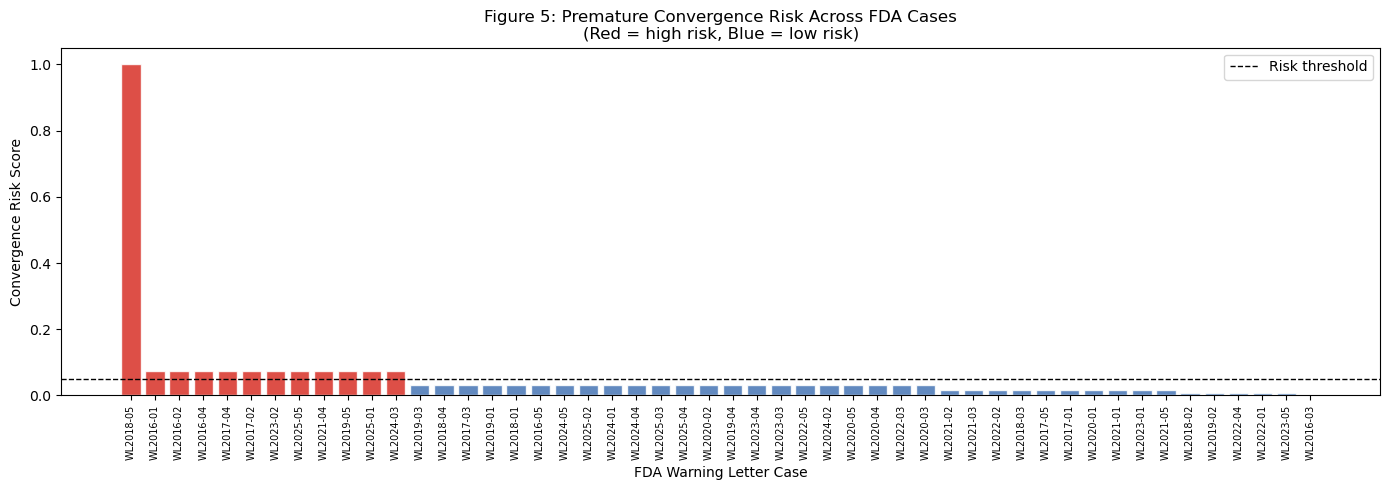

High risk cases (>0.05): 12
Low risk cases: 38


In [20]:
# -------------------------------------------------------------
# Step 18: Figure 5 — Convergence risk across FDA cases
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

sorted_cases = case_features.sort_values('convergence_risk', ascending=False)

colors = ['#d73027' if r > 0.05 else '#4575b4' 
          for r in sorted_cases['convergence_risk']]

ax.bar(range(len(sorted_cases)), 
       sorted_cases['convergence_risk'],
       color=colors, alpha=0.85, edgecolor='white')

ax.axhline(y=0.05, color='black', linestyle='--', 
           linewidth=1, label='Risk threshold')
ax.set_xticks(range(len(sorted_cases)))
ax.set_xticklabels(sorted_cases['CaseID'], 
                   rotation=90, fontsize=7)
ax.set_xlabel('FDA Warning Letter Case')
ax.set_ylabel('Convergence Risk Score')
ax.set_title('Figure 5: Premature Convergence Risk Across FDA Cases\n'
             '(Red = high risk, Blue = low risk)')
ax.legend()

plt.tight_layout()
plt.savefig('figure5_fda_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"High risk cases (>0.05): {(sorted_cases['convergence_risk'] > 0.05).sum()}")
print(f"Low risk cases: {(sorted_cases['convergence_risk'] <= 0.05).sum()}")

In [21]:
# -------------------------------------------------------------
# Step 19: Error Analysis
# Which cases did the model get wrong, and why?
# -------------------------------------------------------------

# Get predictions with actual labels
X_test_df = X_test.copy()
X_test_df['true_label'] = y_test.values
X_test_df['predicted'] = y_pred
X_test_df['correct'] = X_test_df['true_label'] == X_test_df['predicted']

# Separate errors
errors = X_test_df[X_test_df['correct'] == False]
correct = X_test_df[X_test_df['correct'] == True]

print(f"Total test cases: {len(X_test_df)}")
print(f"Correct: {len(correct)} ({len(correct)/len(X_test_df)*100:.1f}%)")
print(f"Errors: {len(errors)} ({len(errors)/len(X_test_df)*100:.1f}%)")

print(f"\nError breakdown:")
print(f"False Positives (predicted premature, actually not): "
      f"{len(errors[errors['predicted']==1])}")
print(f"False Negatives (predicted not premature, actually is): "
      f"{len(errors[errors['predicted']==0])}")

print(f"\nError cases — feature averages:")
print(errors[features_v3].mean().round(3))

print(f"\nCorrect cases — feature averages:")
print(correct[features_v3].mean().round(3))

Total test cases: 100
Correct: 89 (89.0%)
Errors: 11 (11.0%)

Error breakdown:
False Positives (predicted premature, actually not): 8
False Negatives (predicted not premature, actually is): 3

Error cases — feature averages:
explanation_count         2.909
commitment_level          0.909
uncertainty_marker        0.545
alternative_considered    0.636
closure_language          0.545
diversity_score           1.448
dtype: float64

Correct cases — feature averages:
explanation_count         3.517
commitment_level          0.989
uncertainty_marker        0.528
alternative_considered    0.562
closure_language          0.494
diversity_score           1.539
dtype: float64


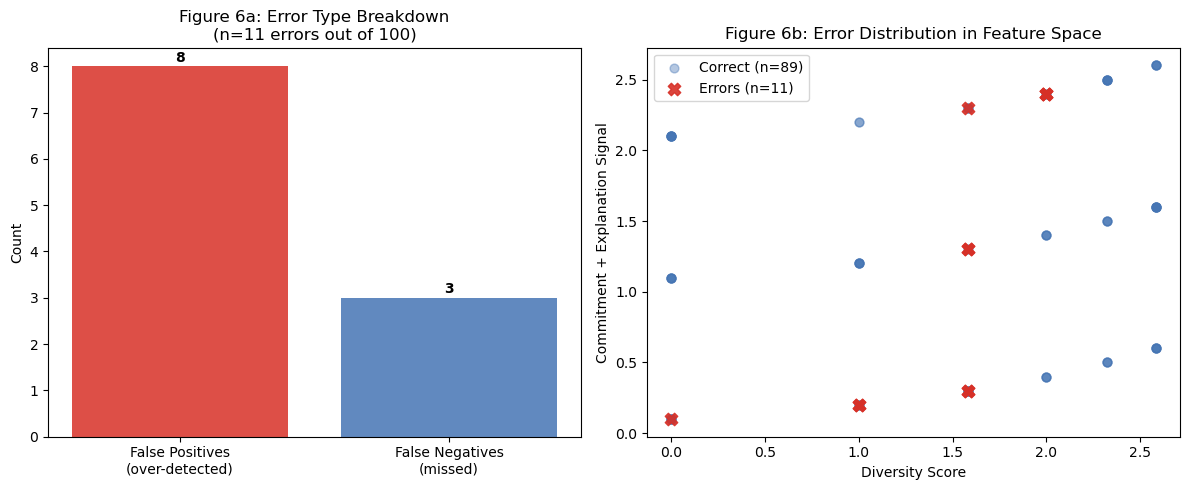

In [22]:
# -------------------------------------------------------------
# Step 20: Visualize errors — Figure 6
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Figure 6a — Error type breakdown
error_types = ['False Positives\n(over-detected)', 
                'False Negatives\n(missed)']
error_counts = [
    len(errors[errors['predicted']==1]),
    len(errors[errors['predicted']==0])
]
colors = ['#d73027', '#4575b4']

axes[0].bar(error_types, error_counts, color=colors, alpha=0.85)
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 6a: Error Type Breakdown\n(n=11 errors out of 100)')
for i, v in enumerate(error_counts):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Figure 6b — diversity score of errors vs correct
axes[1].scatter(
    correct['diversity_score'], 
    correct['commitment_level'] + correct['explanation_count']*0.1,
    alpha=0.4, color='#4575b4', label=f'Correct (n={len(correct)})', s=40
)
axes[1].scatter(
    errors['diversity_score'],
    errors['commitment_level'] + errors['explanation_count']*0.1,
    alpha=0.9, color='#d73027', label=f'Errors (n={len(errors)})', 
    s=80, marker='X'
)
axes[1].set_xlabel('Diversity Score')
axes[1].set_ylabel('Commitment + Explanation Signal')
axes[1].set_title('Figure 6b: Error Distribution in Feature Space')
axes[1].legend()

plt.tight_layout()
plt.savefig('figure6_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# -------------------------------------------------------------
# Step 21: Model Comparison — LR vs Random Forest vs SVM
# Cross-validation for robust evaluation
# -------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

X_all = df_v3[features_v3]
y_all = df_v3['label']

print("5-Fold Cross-Validation Results:")
print("-" * 45)

cv_results = {}
for name, model in models.items():
    # Pipeline with scaler for fair comparison
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_all, y_all, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f"{name:25s}: {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold Cross-Validation Results:
---------------------------------------------
Logistic Regression      : 0.909 ± 0.031
Random Forest            : 0.901 ± 0.031
SVM                      : 0.913 ± 0.036


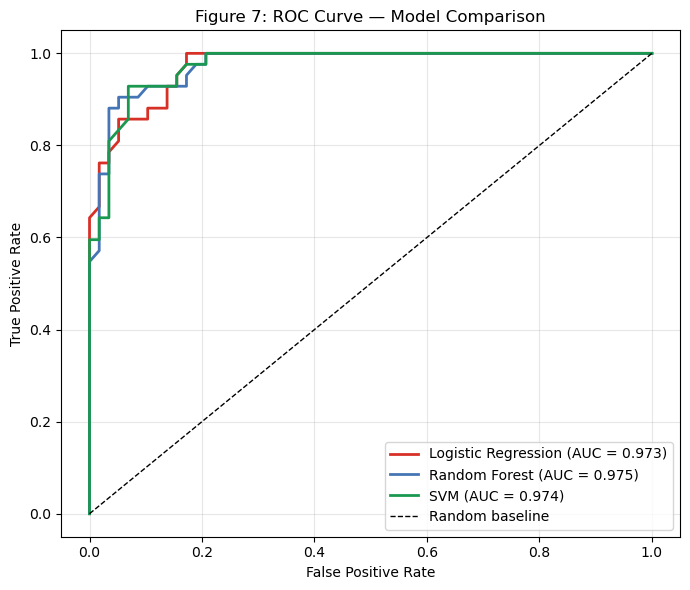

AUC scores saved!


In [24]:
# -------------------------------------------------------------
# Step 22: ROC Curve comparison — Figure 7
# -------------------------------------------------------------

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

colors_roc = ['#d73027', '#4575b4', '#1a9850']

for (name, model), color in zip(models.items(), colors_roc):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 7: ROC Curve — Model Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure7_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("AUC scores saved!")

In [25]:
# -------------------------------------------------------------
# Step 23: Ablation Study
# Remove one feature at a time — how much does F1 drop?
# -------------------------------------------------------------

from sklearn.model_selection import cross_val_score

baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

baseline_score = cross_val_score(
    baseline_pipe, X_all, y_all, cv=5, scoring='f1'
).mean()

print(f"Baseline F1 (all features): {baseline_score:.3f}")
print(f"\nAblation results (remove one feature at a time):")
print("-" * 50)

ablation_results = {}
for feat in features_v3:
    features_minus_one = [f for f in features_v3 if f != feat]
    X_ablation = df_v3[features_minus_one]
    score = cross_val_score(
        baseline_pipe, X_ablation, y_all, cv=5, scoring='f1'
    ).mean()
    drop = baseline_score - score
    ablation_results[feat] = {'score': score, 'drop': drop}
    print(f"  - {feat:25s}: F1 = {score:.3f}  (drop = {drop:+.3f})")

Baseline F1 (all features): 0.909

Ablation results (remove one feature at a time):
--------------------------------------------------
  - explanation_count        : F1 = 0.904  (drop = +0.005)
  - commitment_level         : F1 = 0.849  (drop = +0.060)
  - uncertainty_marker       : F1 = 0.891  (drop = +0.018)
  - alternative_considered   : F1 = 0.912  (drop = -0.003)
  - closure_language         : F1 = 0.918  (drop = -0.009)
  - diversity_score          : F1 = 0.925  (drop = -0.016)


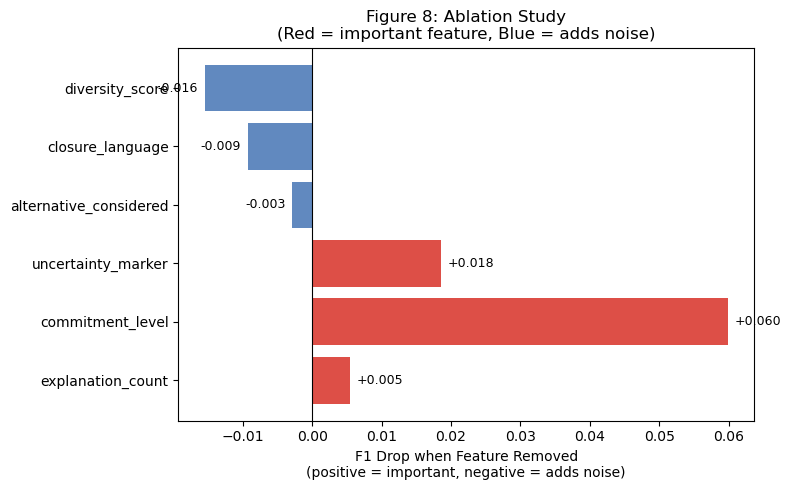

In [26]:
# -------------------------------------------------------------
# Step 24: Ablation Study — Figure 8
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

feats = list(ablation_results.keys())
drops = [ablation_results[f]['drop'] for f in feats]
colors = ['#d73027' if d > 0 else '#4575b4' for d in drops]

bars = ax.barh(feats, drops, color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('F1 Drop when Feature Removed\n(positive = important, negative = adds noise)')
ax.set_title('Figure 8: Ablation Study\n(Red = important feature, Blue = adds noise)')

# Add value labels
for bar, drop in zip(bars, drops):
    ax.text(drop + 0.001 if drop >= 0 else drop - 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{drop:+.3f}', va='center',
            ha='left' if drop >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig('figure8_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# -------------------------------------------------------------
# Step 25: Install SHAP
# -------------------------------------------------------------

import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet'])
import shap

print("SHAP ready!")

SHAP ready!


In [28]:
# -------------------------------------------------------------
# Step 26: SHAP Analysis
# Why did the model make each prediction?
# -------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

# Train Random Forest on full training set (SHAP works best with RF)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# shap_values[1] = values for class 1 (premature)
print("SHAP values computed!")
print(f"Shape: {shap_values[1].shape}")
print(f"\nMean absolute SHAP values (feature importance):")
mean_shap = pd.DataFrame({
    'feature': features_v3,
    'mean_abs_shap': abs(shap_values[1]).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(mean_shap)

SHAP values computed!
Shape: (6, 2)

Mean absolute SHAP values (feature importance):


ValueError: All arrays must be of the same length

In [29]:
# -------------------------------------------------------------
# Step 26 (fixed): SHAP Analysis
# -------------------------------------------------------------

# Check shap_values format
print(f"Type: {type(shap_values)}")
print(f"Length: {len(shap_values)}")

if isinstance(shap_values, list):
    # Old SHAP format — shap_values[1] for class 1
    sv = shap_values[1]
else:
    # New SHAP format — directly usable
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")

# Mean absolute SHAP
mean_shap = pd.DataFrame({
    'feature': features_v3,
    'mean_abs_shap': abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nMean absolute SHAP values:")
print(mean_shap)

Type: <class 'numpy.ndarray'>
Length: 100
SHAP values shape: (100, 6, 2)


ValueError: Per-column arrays must each be 1-dimensional

In [30]:
# -------------------------------------------------------------
# Step 26 (fixed v2): SHAP Analysis
# shap_values shape = (100, 6, 2) → [:, :, 1] for class 1
# -------------------------------------------------------------

# Extract class 1 (premature) SHAP values
sv_class1 = shap_values[:, :, 1]  # shape: (100, 6)
print(f"Class 1 SHAP shape: {sv_class1.shape}")

# Mean absolute SHAP per feature
mean_shap = pd.DataFrame({
    'feature': features_v3,
    'mean_abs_shap': abs(sv_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nMean absolute SHAP values (feature importance):")
print(mean_shap)

Class 1 SHAP shape: (100, 6)

Mean absolute SHAP values (feature importance):
                  feature  mean_abs_shap
0       explanation_count       0.190718
5         diversity_score       0.176742
1        commitment_level       0.117254
2      uncertainty_marker       0.078674
4        closure_language       0.060274
3  alternative_considered       0.029328


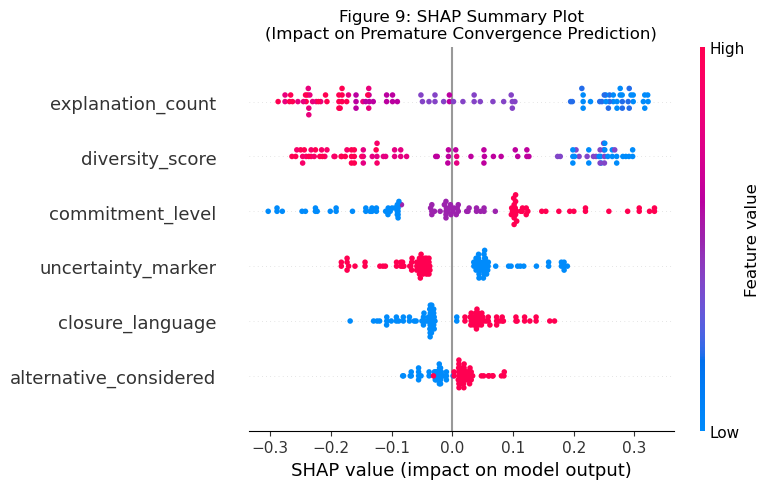

Saved!


In [31]:
# -------------------------------------------------------------
# Step 27: SHAP Summary Plot — Figure 9
# -------------------------------------------------------------

import matplotlib.pyplot as plt

shap.summary_plot(
    sv_class1,
    X_test,
    feature_names=features_v3,
    show=False,
    plot_size=(8, 5)
)

plt.title('Figure 9: SHAP Summary Plot\n(Impact on Premature Convergence Prediction)')
plt.tight_layout()
plt.savefig('figure9_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [32]:
# -------------------------------------------------------------
# Step 28: Table 1 — Model Comparison Summary
# -------------------------------------------------------------

results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'F1 (CV)': [0.909, 0.901, 0.913],
    'F1 std': [0.031, 0.031, 0.036],
    'AUC': [0.973, 0.975, 0.974]
})

print("Table 1: Model Comparison")
print("=" * 50)
print(results_table.to_string(index=False))
print("\nBest AUC:", results_table.loc[results_table['AUC'].idxmax(), 'Model'])
print("Best F1:", results_table.loc[results_table['F1 (CV)'].idxmax(), 'Model'])

Table 1: Model Comparison
              Model  F1 (CV)  F1 std   AUC
Logistic Regression    0.909   0.031 0.973
      Random Forest    0.901   0.031 0.975
                SVM    0.913   0.036 0.974

Best AUC: Random Forest
Best F1: SVM
